# Development of a CNN Model with the MFCC as it's input feature:

## Imports:

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Geral:

In [4]:
SAMPLE_RATE = 16000
N_FFT = 512
HOP_LENGTH = 160
N_MELS = 64
BATCH_SIZE = 32

CLASS_NAMES = np.array(['go', 'no', 'off', 'on', 'stop', '_unknown_'])
NUM_CLASSES = len(CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE

DATASET_PATH = "../Datasets/KWS/KWS/dataset_augmented/"


In [5]:
def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    label = parts[-2]
    return tf.argmax(label == CLASS_NAMES)

In [6]:
def process_audio(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    audio = audio[:SAMPLE_RATE]
    audio = tf.pad(audio, [[0, SAMPLE_RATE - tf.shape(audio)[0]]])

    stft = tf.signal.stft(audio, frame_length=N_FFT, frame_step=HOP_LENGTH, fft_length=N_FFT)
    spectrogram = tf.abs(stft)

    num_spectrogram_bins = spectrogram.shape[-1]

    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MELS,
        num_spectrogram_bins=num_spectrogram_bins,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz= 20,
        upper_edge_hertz= SAMPLE_RATE / 2
    )

    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    means = tf.math.reduce_mean(log_mel_spectrogram)
    stds = tf.math.reduce_std(log_mel_spectrogram)

    log_mel_spectrogram = (log_mel_spectrogram - means) / stds

    return tf.expand_dims(log_mel_spectrogram, -1)

In [7]:
def load_data(file_path):
    label = get_label(file_path)
    spectrogram = process_audio(file_path)
    return spectrogram, label

In [8]:
train_ds = tf.data.Dataset.list_files(f"{DATASET_PATH}/train/*/*.wav")
val_ds = tf.data.Dataset.list_files(f"{DATASET_PATH}/validation/*/*.wav")
test_ds = tf.data.Dataset.list_files(f"{DATASET_PATH}/test/*/*.wav")

I0000 00:00:1764183406.661982   11482 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1138 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


In [9]:
train_ds = (train_ds
    .map(load_data, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (val_ds
    .map(load_data, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (test_ds
    .map(load_data, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

Input shape: (32, 97, 64, 1)
Label shape: (32,)


2025-11-26 15:56:51.249662: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


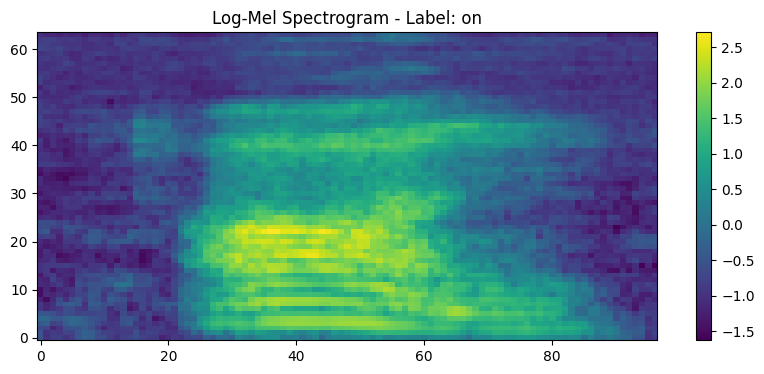

2025-11-26 15:56:51.328685: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
for spec, label in train_ds.take(1):
    print("Input shape:", spec.shape)
    print("Label shape:", label.shape)
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.transpose(spec[0], perm=[1, 0, 2])[:, :, 0], aspect='auto', origin='lower')
    plt.title(f"Log-Mel Spectrogram - Label: {CLASS_NAMES[label[0]]}")
    plt.colorbar()
    plt.show()

In [11]:
input_shape = spec[1].shape
print(input_shape)

(97, 64, 1)


## Training:

In [12]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [13]:
model_log_mel = tf.keras.models.Sequential([
    # Input:
    tf.keras.layers.Input(input_shape),

    # Bloco de Convolução 1
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 2
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 3
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten:
    tf.keras.layers.Flatten(),

    # Bloco Denso para classificação:
    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

model_log_mel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 97, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 97, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 97, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,293,638 (12.56 MB)

 Trainable params: 3,292,358 (12.56 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [14]:
model_log_mel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel/models/model_log_mel.keras', monitor='val_loss', save_best_only=True)
]

In [17]:
history = model_log_mel.fit(train_ds, validation_data=val_ds, callbacks=callbacks, epochs=100, verbose=1)

Epoch 1/100


2025-11-26 15:58:11.595368: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f2bb4015700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-26 15:58:11.595383: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-11-26 15:58:11.629173: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-26 15:58:11.827739: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
2025-11-26 15:58:11.867145: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-26 15:58:11.867175: I e

  25/2273 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.3317 - loss: 1.8118 

I0000 00:00:1764183494.856432   11639 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2273/2273 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8532 - loss: 0.4027 - val_accuracy: 0.8999 - val_loss: 0.2850
Epoch 2/100
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9343 - loss: 0.1823 - val_accuracy: 0.9255 - val_loss: 0.2206
Epoch 3/100
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9586 - loss: 0.1183 - val_accuracy: 0.9263 - val_loss: 0.2475
Epoch 4/100
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9704 - loss: 0.0839 - val_accuracy: 0.9013 - val_loss: 0.3431
Epoch 5/100
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9782 - loss: 0.0621 - val_accuracy: 0.9244 - val_loss: 0.2792
Epoch 6/100
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9824 - loss: 0.0507 - val_accuracy: 0.9135 - val_loss: 0.3242
Epoch 7/100
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9859 - loss: 0.0406 - val_accuracy: 0.9307 - val_loss: 0.2655


## Testing:

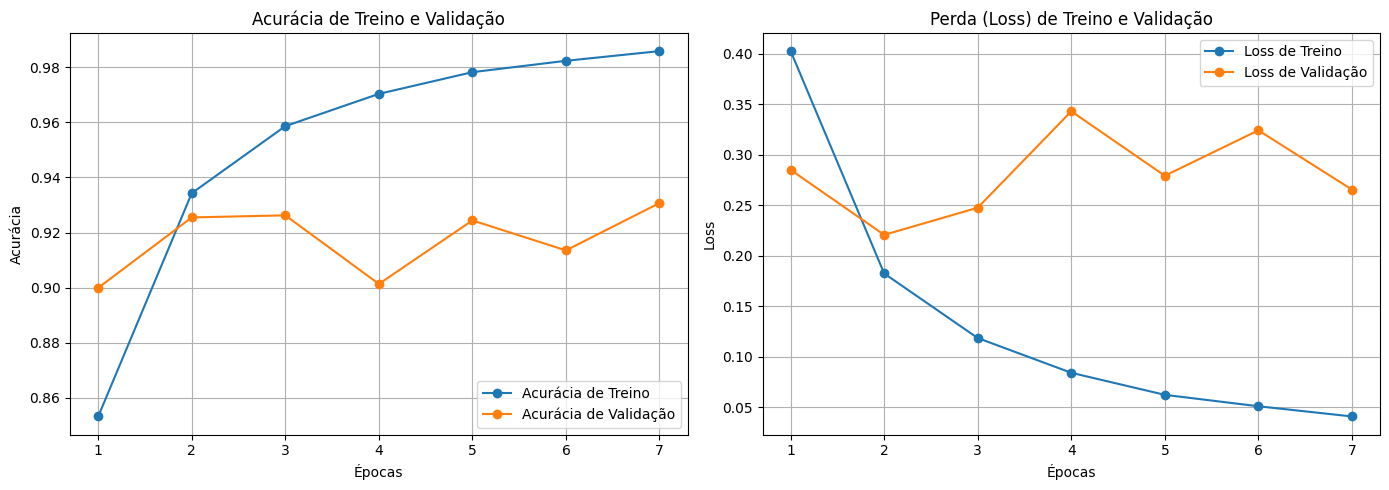

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [19]:
model_log_mel = tf.keras.models.load_model('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel/models/model_log_mel.keras')

y_pred_probs = model_log_mel.predict(test_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.concatenate([y for x, y in test_ds], axis=0)

print("\n--- Relatório de Classificação ---")
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)
print(report)

57/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

2025-11-26 16:00:41.833039: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-26 16:00:42.052974: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 8 bytes spill stores, 8 bytes spill loads



78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

--- Relatório de Classificação ---
              precision    recall  f1-score   support

          go       0.94      0.86      0.90       402
          no       0.92      0.96      0.94       405
         off       0.88      0.96      0.92       402
          on       0.96      0.91      0.93       396
        stop       0.99      0.98      0.99       411
   _unknown_       0.87      0.88      0.87       474

    accuracy                           0.92      2490
   macro avg       0.93      0.92      0.92      2490
weighted avg       0.93      0.92      0.92      2490



2025-11-26 16:00:42.610111: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



--- Matriz de Confusão ---


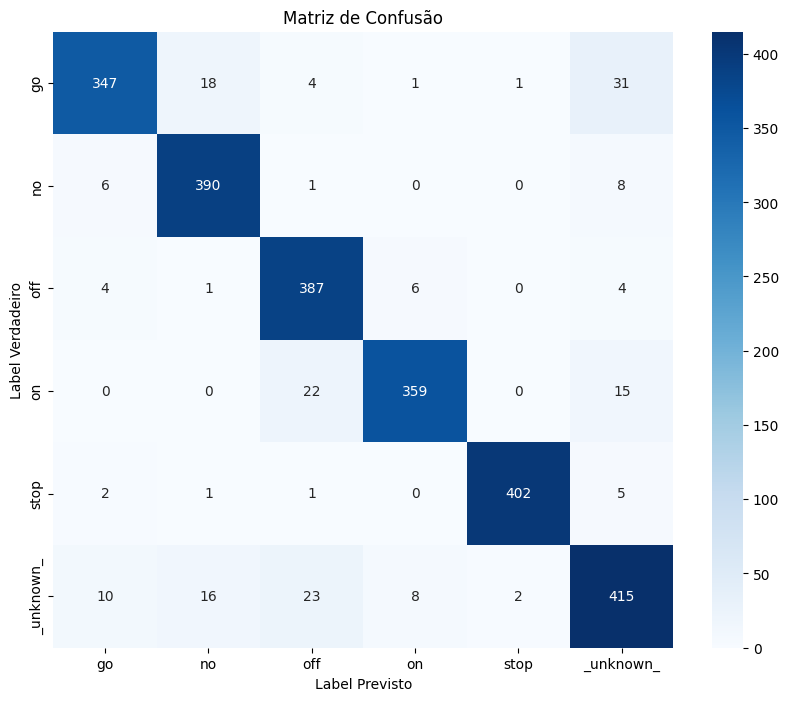

In [20]:
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(y_true_indices, y_pred_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()


## Gerando modelo .tflite (float16):

In [23]:
keras_model = tf.keras.models.load_model("../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel/models/model_log_mel.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

print("\nIniciando conversão com quantização Float16...")

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model_fp16 = converter.convert()

with open("../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel/models/model_log_mel_fp16.tflite", 'wb') as f:
    f.write(tflite_model_fp16)
print(f"Modelo com Float16 Quantization salvo em ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel/models/model_log_mel_fp16.tflite")


Iniciando conversão com quantização Float16...
INFO:tensorflow:Assets written to: /tmp/tmp7hobi3wd/assets


INFO:tensorflow:Assets written to: /tmp/tmp7hobi3wd/assets


Saved artifact at '/tmp/tmp7hobi3wd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 97, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139833481952096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702010368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702417328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702419440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702352144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702354432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702419792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702617632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702619040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702616224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139833702617984: 

W0000 00:00:1764183735.486699   11482 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1764183735.486713   11482 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


Modelo com Float16 Quantization salvo em ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel/models/model_log_mel_fp16.tflite


2025-11-26 16:02:15.486798: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7hobi3wd
2025-11-26 16:02:15.487359: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-11-26 16:02:15.487362: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp7hobi3wd
2025-11-26 16:02:15.492963: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-11-26 16:02:15.539000: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp7hobi3wd
2025-11-26 16:02:15.549079: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 62282 microseconds.


## Testing .tflite model (float16):

In [24]:
TFLITE_MODEL_PATH = Path('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel/models/model_log_mel_fp16.tflite')

print(f"Carregando modelo TFLite de: {TFLITE_MODEL_PATH}")
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("\n--- Detalhes do Modelo TFLite ---")
print(f"Entrada (Shape): {input_details['shape']}")
print(f"Entrada (Tipo): {input_details['dtype']}")
print(f"Saída (Shape): {output_details['shape']}")
print(f"Saída (Tipo): {output_details['dtype']}")

Carregando modelo TFLite de: ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel/models/model_log_mel_fp16.tflite

--- Detalhes do Modelo TFLite ---
Entrada (Shape): [ 1 97 64  1]
Entrada (Tipo): <class 'numpy.float32'>
Saída (Shape): [1 6]
Saída (Tipo): <class 'numpy.float32'>


/home/rolds/Documents/venvs/tensorflow_venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [25]:
y_true = []
y_pred = []
total_samples = 0

print("Iniciando avaliação no dataset de teste...")
for data_batch, labels_batch in test_ds:
    # Iterar sobre cada amostra no lote
    for i in range(data_batch.shape[0]):
        # Pegar uma única amostra de dado
        sample_data = data_batch[i]
        
        # Adicionar a dimensão do lote (batch dimension) para corresponder ao shape da entrada do modelo
        input_tensor = np.expand_dims(sample_data, axis=0).astype(np.float32)

        # Definir o tensor de entrada, executar inferência e obter a saída
        # Não precisamos de nenhuma conversão manual, o interpretador cuida de tudo.
        interpreter.set_tensor(input_details['index'], input_tensor)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])
        
        # Armazenar o rótulo previsto e o rótulo verdadeiro
        predicted_label_index = np.argmax(output_data)
        y_pred.append(predicted_label_index)
        y_true.append(labels_batch[i].numpy())
        
    total_samples += data_batch.shape[0]
    print(f"Avaliadas {total_samples} amostras...")

print("\nAvaliação concluída.")

Iniciando avaliação no dataset de teste...
Avaliadas 32 amostras...
Avaliadas 64 amostras...
Avaliadas 96 amostras...
Avaliadas 128 amostras...
Avaliadas 160 amostras...
Avaliadas 192 amostras...
Avaliadas 224 amostras...
Avaliadas 256 amostras...
Avaliadas 288 amostras...
Avaliadas 320 amostras...
Avaliadas 352 amostras...
Avaliadas 384 amostras...
Avaliadas 416 amostras...
Avaliadas 448 amostras...
Avaliadas 480 amostras...
Avaliadas 512 amostras...
Avaliadas 544 amostras...
Avaliadas 576 amostras...
Avaliadas 608 amostras...
Avaliadas 640 amostras...
Avaliadas 672 amostras...
Avaliadas 704 amostras...
Avaliadas 736 amostras...
Avaliadas 768 amostras...
Avaliadas 800 amostras...
Avaliadas 832 amostras...
Avaliadas 864 amostras...
Avaliadas 896 amostras...
Avaliadas 928 amostras...
Avaliadas 960 amostras...
Avaliadas 992 amostras...
Avaliadas 1024 amostras...
Avaliadas 1056 amostras...
Avaliadas 1088 amostras...
Avaliadas 1120 amostras...
Avaliadas 1152 amostras...
Avaliadas 1184 amos

In [28]:
print("\n--- Relatório de Classificação ---\n")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)


--- Relatório de Classificação ---

              precision    recall  f1-score   support

          go       0.94      0.86      0.90       402
          no       0.92      0.96      0.94       405
         off       0.88      0.96      0.92       402
          on       0.96      0.91      0.93       396
        stop       0.99      0.98      0.99       411
   _unknown_       0.87      0.88      0.87       474

    accuracy                           0.92      2490
   macro avg       0.93      0.92      0.92      2490
weighted avg       0.93      0.92      0.92      2490




--- Matriz de Confusão ---


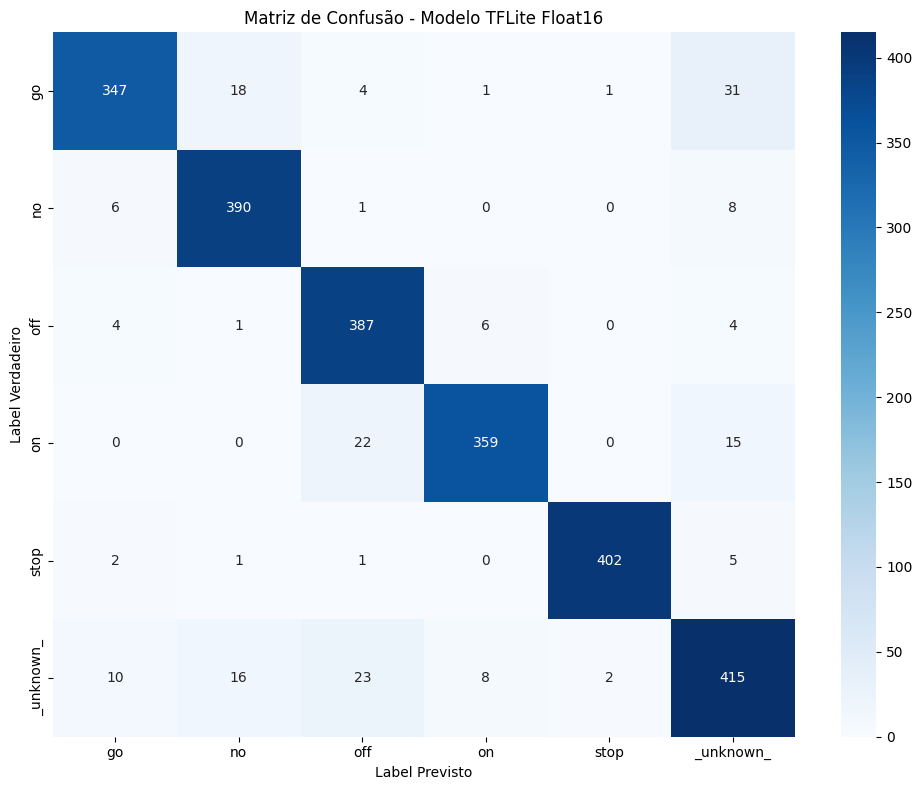

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão - Modelo TFLite Float16')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.tight_layout()
plt.show()